<a href="https://colab.research.google.com/github/Yueuoft/STAD68/blob/main/failure_modes_experiment_workbook_patched_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Failure Modes of Efficient Diffusion Models — Experiment Notebook

This notebook packages the experiment plan, implementation notes, troubleshooting tips, and runnable code for the project **Failure Modes of Efficient Diffusion Models**.

## Main thesis

**Efficiency-driven acceleration causes diversity to collapse before semantic alignment fully breaks.**

## Priority order

1. Step sweep: teacher vs LCM at different inference steps  
2. CFG sweep: does acceleration amplify guidance instability?  
3. Negative prompt sensitivity  
4. Compositional prompts  
5. Fine-detail prompts  
6. Early commitment visualization

## What this notebook gives you

- structured prompt suites
- reproducible teacher–student pipeline
- LPIPS diversity, CLIP feature variance, CLIP alignment
- step sweep, CFG sweep, negative prompt experiments
- compositional and fine-detail qualitative runs
- plotting and aggregation
- troubleshooting note for the Pillow import error

## Environment setup

Run the next cell first in Colab or Jupyter.

In [1]:
!pip -q install -U diffusers transformers accelerate safetensors ftfy sentencepiece lpips matplotlib pandas scikit-learn pillow torchvision

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 5.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 124.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 134.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 95.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 151.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 130.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.1 which is incompatible.
cudf-cu12 26.2.1 require

## Pillow import fix

If you hit this error:

```python
ImportError: cannot import name '_Ink' from 'PIL._typing'
```

run the next cell, then **restart the runtime/kernel**, and test the import again.

In [2]:
!pip uninstall -y pillow PIL
!pip install --no-cache-dir --force-reinstall pillow==10.4.0

# After this, restart the runtime / kernel, then test:
from PIL import Image, ImageDraw
print("PIL import success")

Found existing installation: pillow 12.1.1
Uninstalling pillow-12.1.1:
  Successfully uninstalled pillow-12.1.1
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 83.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.1 which is incompatible.


PIL import success


## Imports

In [1]:
import os
import math
import json
import random
from dataclasses import dataclass, field, asdict
from itertools import combinations
from typing import List, Dict, Any, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from tqdm.auto import tqdm

import torch
import torchvision.transforms as T

from diffusers import StableDiffusionPipeline, DDIMScheduler, LCMScheduler
from transformers import CLIPProcessor, CLIPModel
import lpips

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


## Experiment design notes

Use one base model and one accelerated version of the **same backbone**.

### Recommended model pair
- **Teacher**: `runwayml/stable-diffusion-v1-5`
- **Student**: `runwayml/stable-diffusion-v1-5` + `latent-consistency/lcm-lora-sdv1-5`

### Why this setup
- lighter than SDXL
- easier to run in Colab
- cleaner comparison
- same base family

### Main expected claims
- fewer steps → lower LPIPS diversity
- fewer steps → lower CLIP image-feature variance
- CLIP alignment degrades more slowly
- high CFG can destabilize accelerated models
- accelerated models may respond more weakly to negative prompts
- compositional and fine-detail failures can appear while CLIP alignment still looks acceptable

## Prompt suite

Keep the prompt set structured instead of random. This makes the paper much easier to defend.

In [2]:
PROMPTS = {
    "diversity": [
        "a cinematic portrait of a fox in a snowy forest at dawn",
        "a watercolor painting of a lighthouse on a rocky coast during sunset",
        "a futuristic city street after rain with neon reflections",
        "a cozy reading room with warm lamps and many books",
    ],
    "composition": [
        "a red cube on top of a blue sphere on a wooden table",
        "a cat wearing round glasses reading a book in a library",
        "a small yellow bird sitting inside a white teacup next to a silver spoon",
        "a green bicycle leaning against a brick wall under a street lamp",
    ],
    "fine_detail": [
        "a close-up photo of a wristwatch showing 10:08 with visible numbers and metal texture",
        "a storefront sign with clear readable text saying OPEN DAILY",
        "a detailed sketch of thin tree branches covered with frost",
        "a macro photo of a circuit board with tiny labeled components",
    ],
    "control": [
        "a realistic photo of a black dog running on a beach",
        "a realistic photo of a white car parked in front of a blue house",
        "a bowl of strawberries on a marble kitchen counter",
        "a city skyline at night with reflections in the river",
    ],
}

NEGATIVE_PROMPTS = {
    "none": "",
    "generic": "blurry, low quality, distorted, deformed, extra limbs",
    "dog_targeted": "sand, ocean, beach, water, shoreline",
    "car_targeted": "blue house, house, trees, people",
}

## Configuration

For the first safe Colab run, use:
- `max_prompts_per_group = 2`
- `seeds = [0, 1, 2, 3]`

Once it works, scale up.

In [3]:
@dataclass
class ExperimentConfig:
    base_model_id: str = "runwayml/stable-diffusion-v1-5"
    lcm_lora_id: str = "latent-consistency/lcm-lora-sdv1-5"

    image_size: int = 512
    teacher_steps: List[int] = field(default_factory=lambda: [30])
    student_steps: List[int] = field(default_factory=lambda: [8, 4, 2])

    teacher_cfg_default: float = 7.5
    student_cfg_default: float = 2.0

    teacher_cfg_sweep: List[float] = field(default_factory=lambda: [3, 5, 7.5, 10, 12])
    student_cfg_sweep: List[float] = field(default_factory=lambda: [1, 2, 4, 6, 8])

    seeds: List[int] = field(default_factory=lambda: list(range(4)))  # change to range(8) later
    device: str = "cuda" if torch.cuda.is_available() else "cpu"
    dtype: Any = torch.float16 if torch.cuda.is_available() else torch.float32

    output_root: str = "outputs"
    save_individual_images: bool = True
    save_grids: bool = True
    save_plots: bool = True

    max_prompts_per_group: Optional[int] = 2

    use_attention_slicing: bool = True
    use_vae_slicing: bool = True

    def make_dirs(self):
        os.makedirs(self.output_root, exist_ok=True)
        os.makedirs(os.path.join(self.output_root, "images"), exist_ok=True)
        os.makedirs(os.path.join(self.output_root, "grids"), exist_ok=True)
        os.makedirs(os.path.join(self.output_root, "metrics"), exist_ok=True)
        os.makedirs(os.path.join(self.output_root, "plots"), exist_ok=True)
        os.makedirs(os.path.join(self.output_root, "configs"), exist_ok=True)
        os.makedirs(os.path.join(self.output_root, "callbacks"), exist_ok=True)

CFG = ExperimentConfig()
CFG.make_dirs()
print(json.dumps(asdict(CFG), indent=2, default=str))

{
  "base_model_id": "runwayml/stable-diffusion-v1-5",
  "lcm_lora_id": "latent-consistency/lcm-lora-sdv1-5",
  "image_size": 512,
  "teacher_steps": [
    30
  ],
  "student_steps": [
    8,
    4,
    2
  ],
  "teacher_cfg_default": 7.5,
  "student_cfg_default": 2.0,
  "teacher_cfg_sweep": [
    3,
    5,
    7.5,
    10,
    12
  ],
  "student_cfg_sweep": [
    1,
    2,
    4,
    6,
    8
  ],
  "seeds": [
    0,
    1,
    2,
    3
  ],
  "device": "cuda",
  "dtype": "torch.float16",
  "output_root": "outputs",
  "save_individual_images": true,
  "save_grids": true,
  "save_plots": true,
  "max_prompts_per_group": 2,
  "use_attention_slicing": true,
  "use_vae_slicing": true
}


## Utility helpers

In [4]:
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

def save_json(obj: Dict[str, Any], path: str):
    with open(path, "w") as f:
        json.dump(obj, f, indent=2)

def get_prompt_dict_subset(prompts: Dict[str, List[str]], max_per_group: Optional[int]):
    if max_per_group is None:
        return prompts
    return {k: v[:max_per_group] for k, v in prompts.items()}

def sanitize_filename(text: str, max_len: int = 140) -> str:
    text = text.replace("/", "-").replace(" ", "_")
    keep = []
    for ch in text:
        if ch.isalnum() or ch in "-_.":
            keep.append(ch)
    return "".join(keep)[:max_len]

## Load teacher and student pipelines

In [5]:
def optimize_pipe(pipe, cfg: ExperimentConfig):
    pipe.set_progress_bar_config(disable=True)
    if cfg.use_attention_slicing and hasattr(pipe, "enable_attention_slicing"):
        pipe.enable_attention_slicing()
    if cfg.use_vae_slicing and hasattr(pipe, "enable_vae_slicing"):
        pipe.enable_vae_slicing()
    return pipe

def load_teacher_pipeline(cfg: ExperimentConfig):
    pipe = StableDiffusionPipeline.from_pretrained(
        cfg.base_model_id,
        torch_dtype=cfg.dtype,
        safety_checker=None
    )
    pipe.scheduler = DDIMScheduler.from_config(pipe.scheduler.config)
    pipe = pipe.to(cfg.device)
    pipe = optimize_pipe(pipe, cfg)
    return pipe

def load_student_pipeline(cfg: ExperimentConfig):
    pipe = StableDiffusionPipeline.from_pretrained(
        cfg.base_model_id,
        torch_dtype=cfg.dtype,
        safety_checker=None
    )
    pipe.load_lora_weights(cfg.lcm_lora_id)
    pipe.fuse_lora()
    pipe.scheduler = LCMScheduler.from_config(pipe.scheduler.config)
    pipe = pipe.to(cfg.device)
    pipe = optimize_pipe(pipe, cfg)
    return pipe

# Run this once
teacher_pipe = load_teacher_pipeline(CFG)
student_pipe = load_student_pipeline(CFG)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its resul

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its resul

## Generation helpers

In [6]:
def autocast_context(device: str):
    if device == "cuda":
        return torch.autocast("cuda")
    return torch.autocast("cpu")

def generate_image(
    pipe,
    prompt: str,
    seed: int,
    num_inference_steps: int,
    guidance_scale: float,
    negative_prompt: str = "",
    image_size: int = 512
) -> Image.Image:
    generator = torch.Generator(device=CFG.device).manual_seed(seed)

    with autocast_context(CFG.device):
        output = pipe(
            prompt=prompt,
            negative_prompt=negative_prompt if negative_prompt else None,
            num_inference_steps=num_inference_steps,
            guidance_scale=guidance_scale,
            generator=generator,
            height=image_size,
            width=image_size
        )
    return output.images[0]

def save_image(img: Image.Image, path: str):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    img.save(path)

def build_image_filename(
    model_name: str,
    experiment_name: str,
    prompt_group: str,
    prompt_id: int,
    steps: int,
    cfg_scale: float,
    seed: int,
    neg_label: str = "none"
) -> str:
    fname = (
        f"{model_name}__exp-{experiment_name}__group-{prompt_group}"
        f"__pid-{prompt_id}__steps-{steps}__cfg-{cfg_scale}"
        f"__neg-{neg_label}__seed-{seed}.png"
    )
    return sanitize_filename(fname)

def run_setting(
    pipe,
    model_name: str,
    experiment_name: str,
    prompt_group: str,
    prompt_id: int,
    prompt: str,
    steps: int,
    guidance_scale: float,
    seeds: List[int],
    negative_prompt: str = "",
    neg_label: str = "none",
    cfg: ExperimentConfig = CFG
) -> pd.DataFrame:
    rows = []

    for seed in tqdm(seeds, desc=f"{model_name} | {prompt_group} | p{prompt_id} | s{steps} | cfg{guidance_scale}", leave=False):
        img = generate_image(
            pipe=pipe,
            prompt=prompt,
            seed=seed,
            num_inference_steps=steps,
            guidance_scale=guidance_scale,
            negative_prompt=negative_prompt,
            image_size=cfg.image_size
        )

        image_path = os.path.join(
            cfg.output_root,
            "images",
            build_image_filename(
                model_name=model_name,
                experiment_name=experiment_name,
                prompt_group=prompt_group,
                prompt_id=prompt_id,
                steps=steps,
                cfg_scale=guidance_scale,
                seed=seed,
                neg_label=neg_label
            )
        )

        if cfg.save_individual_images:
            save_image(img, image_path)

        rows.append({
            "model": model_name,
            "experiment_name": experiment_name,
            "prompt_group": prompt_group,
            "prompt_id": prompt_id,
            "prompt": prompt,
            "steps": steps,
            "guidance_scale": guidance_scale,
            "seed": seed,
            "negative_prompt": negative_prompt,
            "negative_prompt_label": neg_label,
            "image_path": image_path
        })

    return pd.DataFrame(rows)

## Metrics

The three main metrics are:
- **LPIPS diversity**
- **CLIP feature variance**
- **CLIP text-image alignment**

Interpretation:
- LPIPS down → perceptual diversity collapse
- CLIP feature variance down → semantic diversity shrinking
- CLIP alignment staying relatively stable while diversity collapses → strongest paper result

In [10]:

class Evaluator:
    def __init__(self, cfg):
        self.cfg = cfg
        self.device = cfg.device

        self.lpips_model = lpips.LPIPS(net="alex").to(self.device)
        self.clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(self.device)
        self.clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

        self.lpips_transform = T.Compose([
            T.Resize((cfg.image_size, cfg.image_size)),
            T.ToTensor(),
            T.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
        ])

    def load_images(self, image_paths):
        return [Image.open(p).convert("RGB") for p in image_paths]

    def compute_lpips_diversity(self, images):
        if len(images) < 2:
            return 0.0

        tensors = [self.lpips_transform(img).unsqueeze(0).to(self.device) for img in images]
        scores = []

        with torch.no_grad():
            for i, j in combinations(range(len(tensors)), 2):
                d = self.lpips_model(tensors[i], tensors[j]).item()
                scores.append(d)

        return float(np.mean(scores)) if scores else 0.0

    def _normalize_embeddings(self, feats):
        feats = feats.float()
        return feats / feats.norm(dim=-1, keepdim=True).clamp(min=1e-12)

    def _extract_embedding_tensor(self, output, kind="image"):
        # Handle differences across transformers versions.
        if isinstance(output, torch.Tensor):
            return output

        preferred_keys = []
        if kind == "image":
            preferred_keys = ["image_embeds", "pooler_output", "last_hidden_state"]
        else:
            preferred_keys = ["text_embeds", "pooler_output", "last_hidden_state"]

        for key in preferred_keys:
            if hasattr(output, key):
                value = getattr(output, key)
                if value is not None:
                    # last_hidden_state is [B, L, D]; use CLS token
                    if key == "last_hidden_state" and value.ndim == 3:
                        return value[:, 0, :]
                    return value

        if hasattr(output, "to_tuple"):
            vals = output.to_tuple()
            if len(vals) > 0:
                value = vals[0]
                if isinstance(value, torch.Tensor):
                    if value.ndim == 3:
                        return value[:, 0, :]
                    return value

        raise TypeError(f"Could not extract embedding tensor from output of type {type(output)}")

    def get_clip_image_embeddings(self, images):
        inputs = self.clip_processor(images=images, return_tensors="pt")
        inputs = {k: v.to(self.device) for k, v in inputs.items()}

        with torch.no_grad():
            output = self.clip_model.get_image_features(pixel_values=inputs["pixel_values"])
            feats = self._extract_embedding_tensor(output, kind="image")
            feats = self._normalize_embeddings(feats)

        return feats

    def get_clip_text_embeddings(self, texts):
        inputs = self.clip_processor(text=texts, return_tensors="pt", padding=True, truncation=True)
        inputs = {k: v.to(self.device) for k, v in inputs.items()}

        with torch.no_grad():
            output = self.clip_model.get_text_features(
                input_ids=inputs["input_ids"],
                attention_mask=inputs["attention_mask"]
            )
            feats = self._extract_embedding_tensor(output, kind="text")
            feats = self._normalize_embeddings(feats)

        return feats

    def compute_clip_feature_variance(self, images):
        feats = self.get_clip_image_embeddings(images)
        return float(feats.var(dim=0).mean().item())

    def compute_clip_alignment(self, images, prompt):
        image_feats = self.get_clip_image_embeddings(images)
        text_feats = self.get_clip_text_embeddings([prompt])
        sims = image_feats @ text_feats.T
        return float(sims.mean().item())

    def evaluate_setting(self, df_setting):
        images = self.load_images(df_setting["image_path"].tolist())
        prompt = df_setting["prompt"].iloc[0]

        lpips_div = self.compute_lpips_diversity(images)
        clip_var = self.compute_clip_feature_variance(images)
        clip_align = self.compute_clip_alignment(images, prompt)

        return {
            "model": df_setting["model"].iloc[0],
            "experiment_name": df_setting["experiment_name"].iloc[0],
            "prompt_group": df_setting["prompt_group"].iloc[0],
            "prompt_id": int(df_setting["prompt_id"].iloc[0]),
            "prompt": prompt,
            "steps": int(df_setting["steps"].iloc[0]),
            "guidance_scale": float(df_setting["guidance_scale"].iloc[0]),
            "negative_prompt": df_setting["negative_prompt"].iloc[0],
            "negative_prompt_label": df_setting["negative_prompt_label"].iloc[0],
            "lpips_div": lpips_div,
            "clip_feature_var": clip_var,
            "clip_align": clip_align,
            "n_samples": int(len(images)),
        }
evaluator = Evaluator(CFG)

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 183MB/s]


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth


...

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

### Patch applied for the CLIP text/image feature bug

This notebook now uses `get_text_features(...)` and `get_image_features(...)` instead of the full `CLIPModel(...)` forward path.

After opening this patched notebook, rerun:
1. the imports/setup cells
2. the `Evaluator` cell
3. `evaluator = Evaluator(CFG)`
4. the experiment cells


## Grid helpers

In [11]:
def make_grid(images: List[Image.Image], rows: int, cols: int, bg_color=(255, 255, 255)) -> Image.Image:
    assert len(images) <= rows * cols
    w, h = images[0].size
    grid = Image.new("RGB", (cols * w, rows * h), color=bg_color)
    for idx, img in enumerate(images):
        r = idx // cols
        c = idx % cols
        grid.paste(img, (c * w, r * h))
    return grid

def save_seed_grid(df_setting: pd.DataFrame, out_dir: str, title_stub: str, cols: int = 4):
    image_paths = df_setting["image_path"].tolist()
    images = [Image.open(p).convert("RGB") for p in image_paths]
    rows = math.ceil(len(images) / cols)
    grid = make_grid(images, rows=rows, cols=cols)
    out_path = os.path.join(out_dir, sanitize_filename(f"{title_stub}.png"))
    grid.save(out_path)
    return out_path

## Main experiment 1: step sweep

This is the core quantitative experiment and should be the first one you finish.

### What you want to show
- step count decreases
- LPIPS diversity drops
- CLIP feature variance drops
- CLIP alignment drops more slowly

In [12]:
def run_step_sweep(
    teacher_pipe,
    student_pipe,
    evaluator: Evaluator,
    prompts: Dict[str, List[str]],
    cfg: ExperimentConfig = CFG
):
    all_runs = []
    all_metrics = []

    for prompt_group, prompt_list in prompts.items():
        for prompt_id, prompt in enumerate(prompt_list):
            for steps in cfg.teacher_steps:
                df_run = run_setting(
                    pipe=teacher_pipe,
                    model_name="teacher",
                    experiment_name="step_sweep",
                    prompt_group=prompt_group,
                    prompt_id=prompt_id,
                    prompt=prompt,
                    steps=steps,
                    guidance_scale=cfg.teacher_cfg_default,
                    seeds=cfg.seeds,
                    cfg=cfg
                )
                all_runs.append(df_run)
                all_metrics.append(evaluator.evaluate_setting(df_run))
                if cfg.save_grids:
                    save_seed_grid(df_run, os.path.join(cfg.output_root, "grids"),
                                   f"grid__step_sweep__teacher__{prompt_group}__pid-{prompt_id}__steps-{steps}")

            for steps in cfg.student_steps:
                df_run = run_setting(
                    pipe=student_pipe,
                    model_name="fast_lcm",
                    experiment_name="step_sweep",
                    prompt_group=prompt_group,
                    prompt_id=prompt_id,
                    prompt=prompt,
                    steps=steps,
                    guidance_scale=cfg.student_cfg_default,
                    seeds=cfg.seeds,
                    cfg=cfg
                )
                all_runs.append(df_run)
                all_metrics.append(evaluator.evaluate_setting(df_run))
                if cfg.save_grids:
                    save_seed_grid(df_run, os.path.join(cfg.output_root, "grids"),
                                   f"grid__step_sweep__fast_lcm__{prompt_group}__pid-{prompt_id}__steps-{steps}")

    runs_df = pd.concat(all_runs, ignore_index=True)
    metrics_df = pd.DataFrame(all_metrics)

    runs_df.to_csv(os.path.join(cfg.output_root, "metrics", "step_sweep_runs.csv"), index=False)
    metrics_df.to_csv(os.path.join(cfg.output_root, "metrics", "step_sweep_metrics.csv"), index=False)
    return runs_df, metrics_df

prompts_subset = get_prompt_dict_subset(PROMPTS, CFG.max_prompts_per_group)
step_runs_df, step_metrics_df = run_step_sweep(teacher_pipe, student_pipe, evaluator, prompts_subset, CFG)
step_metrics_df.head()

teacher | diversity | p0 | s30 | cfg7.5:   0%|          | 0/4 [00:00<?, ?it/s]

fast_lcm | diversity | p0 | s8 | cfg2.0:   0%|          | 0/4 [00:00<?, ?it/s]

fast_lcm | diversity | p0 | s4 | cfg2.0:   0%|          | 0/4 [00:00<?, ?it/s]

fast_lcm | diversity | p0 | s2 | cfg2.0:   0%|          | 0/4 [00:00<?, ?it/s]

teacher | diversity | p1 | s30 | cfg7.5:   0%|          | 0/4 [00:00<?, ?it/s]

...

teacher | control | p1 | s30 | cfg7.5:   0%|          | 0/4 [00:00<?, ?it/s]

fast_lcm | control | p1 | s8 | cfg2.0:   0%|          | 0/4 [00:00<?, ?it/s]

fast_lcm | control | p1 | s4 | cfg2.0:   0%|          | 0/4 [00:00<?, ?it/s]

fast_lcm | control | p1 | s2 | cfg2.0:   0%|          | 0/4 [00:00<?, ?it/s]

,model,experiment_name,prompt_group,prompt_id,prompt,steps,guidance_scale,negative_prompt,negative_prompt_label,lpips_div,clip_feature_var,clip_align,n_samples
0,teacher,step_sweep,diversity,0,a cinematic portrait of a fox in a snowy fores...,30,7.5,,none,0.806491,0.000228,0.343154,4
1,fast_lcm,step_sweep,diversity,0,a cinematic portrait of a fox in a snowy fores...,8,2.0,,none,0.780935,0.000230,0.342688,4
2,fast_lcm,step_sweep,diversity,0,a cinematic portrait of a fox in a snowy fores...,4,2.0,,none,0.718851,0.000192,0.333212,4
3,fast_lcm,step_sweep,diversity,0,a cinematic portrait of a fox in a snowy fores...,2,2.0,,none,0.732161,0.000368,0.334326,4
4,teacher,step_sweep,diversity,1,a watercolor painting of a lighthouse on a roc...,30,7.5,,none,0.755856,0.000193,0.368571,4


## Aggregate and plot the step sweep

In [13]:
step_agg_df = (
    step_metrics_df
    .groupby(["model", "steps"], as_index=False)[["lpips_div", "clip_feature_var", "clip_align"]]
    .mean()
    .sort_values(["model", "steps"])
)
step_agg_df

,model,steps,lpips_div,clip_feature_var,clip_align
0,fast_lcm,2,0.835899,0.000308,0.302489
1,fast_lcm,4,0.827683,0.000276,0.319131
2,fast_lcm,8,0.833345,0.000303,0.323132
3,teacher,30,0.792678,0.000297,0.332250


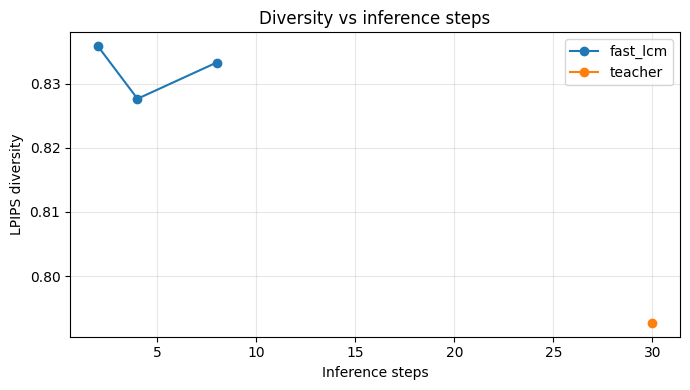

In [14]:
plt.figure(figsize=(7, 4))
for model_name in step_agg_df["model"].unique():
    sub = step_agg_df[step_agg_df["model"] == model_name].sort_values("steps")
    plt.plot(sub["steps"], sub["lpips_div"], marker="o", label=model_name)
plt.xlabel("Inference steps")
plt.ylabel("LPIPS diversity")
plt.title("Diversity vs inference steps")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

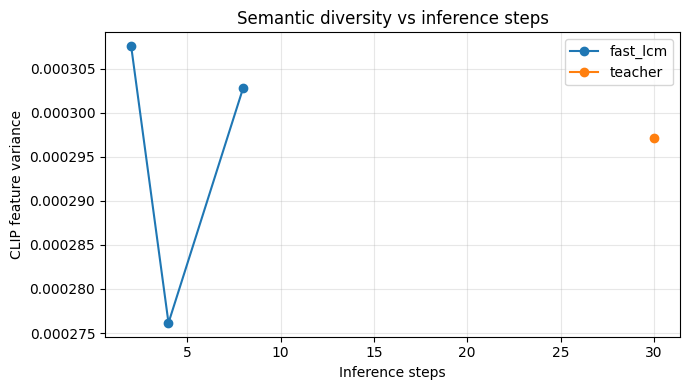

In [15]:
plt.figure(figsize=(7, 4))
for model_name in step_agg_df["model"].unique():
    sub = step_agg_df[step_agg_df["model"] == model_name].sort_values("steps")
    plt.plot(sub["steps"], sub["clip_feature_var"], marker="o", label=model_name)
plt.xlabel("Inference steps")
plt.ylabel("CLIP feature variance")
plt.title("Semantic diversity vs inference steps")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

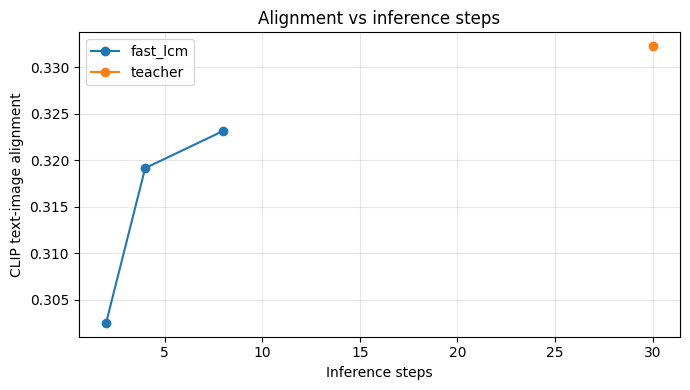

In [16]:
plt.figure(figsize=(7, 4))
for model_name in step_agg_df["model"].unique():
    sub = step_agg_df[step_agg_df["model"] == model_name].sort_values("steps")
    plt.plot(sub["steps"], sub["clip_align"], marker="o", label=model_name)
plt.xlabel("Inference steps")
plt.ylabel("CLIP text-image alignment")
plt.title("Alignment vs inference steps")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

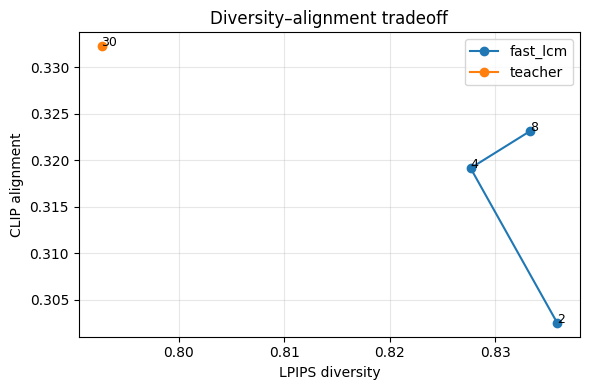

In [17]:
plt.figure(figsize=(6, 4))
for model_name in step_agg_df["model"].unique():
    sub = step_agg_df[step_agg_df["model"] == model_name]
    plt.plot(sub["lpips_div"], sub["clip_align"], marker="o", label=model_name)
for _, row in step_agg_df.iterrows():
    plt.annotate(f"{int(row['steps'])}", (row["lpips_div"], row["clip_align"]), fontsize=9)
plt.xlabel("LPIPS diversity")
plt.ylabel("CLIP alignment")
plt.title("Diversity–alignment tradeoff")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

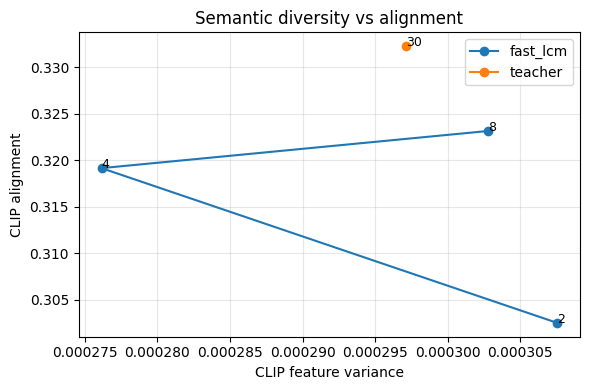

In [18]:
plt.figure(figsize=(6, 4))
for model_name in step_agg_df["model"].unique():
    sub = step_agg_df[step_agg_df["model"] == model_name]
    plt.plot(sub["clip_feature_var"], sub["clip_align"], marker="o", label=model_name)
for _, row in step_agg_df.iterrows():
    plt.annotate(f"{int(row['steps'])}", (row["clip_feature_var"], row["clip_align"]), fontsize=9)
plt.xlabel("CLIP feature variance")
plt.ylabel("CLIP alignment")
plt.title("Semantic diversity vs alignment")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## How to read the main result

If you observe:
- LPIPS diversity ↓ clearly
- CLIP feature variance ↓ clearly
- CLIP alignment ↓ slowly

then your strongest conclusion is:

> Accelerated diffusion loses distributional coverage before it loses coarse semantic faithfulness.

That is the cleanest version of your paper's core result.

## Main experiment 2: CFG instability sweep

### What to look for
- accelerated model becomes visually brittle at high CFG
- diversity shrinks as CFG increases
- CLIP alignment may plateau while images look worse

In [19]:
def run_cfg_sweep(
    teacher_pipe,
    student_pipe,
    evaluator: Evaluator,
    prompts: List[str],
    cfg: ExperimentConfig = CFG
):
    all_runs = []
    all_metrics = []

    for prompt_id, prompt in enumerate(prompts):
        for g in cfg.teacher_cfg_sweep:
            df_run = run_setting(
                pipe=teacher_pipe,
                model_name="teacher",
                experiment_name="cfg_sweep",
                prompt_group="cfg_sweep",
                prompt_id=prompt_id,
                prompt=prompt,
                steps=cfg.teacher_steps[0],
                guidance_scale=g,
                seeds=cfg.seeds[:4],
                cfg=cfg
            )
            all_runs.append(df_run)
            all_metrics.append(evaluator.evaluate_setting(df_run))

        for g in cfg.student_cfg_sweep:
            df_run = run_setting(
                pipe=student_pipe,
                model_name="fast_lcm",
                experiment_name="cfg_sweep",
                prompt_group="cfg_sweep",
                prompt_id=prompt_id,
                prompt=prompt,
                steps=4,
                guidance_scale=g,
                seeds=cfg.seeds[:4],
                cfg=cfg
            )
            all_runs.append(df_run)
            all_metrics.append(evaluator.evaluate_setting(df_run))

    runs_df = pd.concat(all_runs, ignore_index=True)
    metrics_df = pd.DataFrame(all_metrics)
    runs_df.to_csv(os.path.join(cfg.output_root, "metrics", "cfg_sweep_runs.csv"), index=False)
    metrics_df.to_csv(os.path.join(cfg.output_root, "metrics", "cfg_sweep_metrics.csv"), index=False)
    return runs_df, metrics_df

cfg_prompt_subset = prompts_subset["control"][:2]
cfg_runs_df, cfg_metrics_df = run_cfg_sweep(teacher_pipe, student_pipe, evaluator, cfg_prompt_subset, CFG)
cfg_metrics_df.head()

teacher | cfg_sweep | p0 | s30 | cfg3:   0%|          | 0/4 [00:00<?, ?it/s]

teacher | cfg_sweep | p0 | s30 | cfg5:   0%|          | 0/4 [00:00<?, ?it/s]

teacher | cfg_sweep | p0 | s30 | cfg7.5:   0%|          | 0/4 [00:00<?, ?it/s]

teacher | cfg_sweep | p0 | s30 | cfg10:   0%|          | 0/4 [00:00<?, ?it/s]

teacher | cfg_sweep | p0 | s30 | cfg12:   0%|          | 0/4 [00:00<?, ?it/s]

...

fast_lcm | cfg_sweep | p1 | s4 | cfg2:   0%|          | 0/4 [00:00<?, ?it/s]

fast_lcm | cfg_sweep | p1 | s4 | cfg4:   0%|          | 0/4 [00:00<?, ?it/s]

fast_lcm | cfg_sweep | p1 | s4 | cfg6:   0%|          | 0/4 [00:00<?, ?it/s]

fast_lcm | cfg_sweep | p1 | s4 | cfg8:   0%|          | 0/4 [00:00<?, ?it/s]

,model,experiment_name,prompt_group,prompt_id,prompt,steps,guidance_scale,negative_prompt,negative_prompt_label,lpips_div,clip_feature_var,clip_align,n_samples
0,teacher,cfg_sweep,cfg_sweep,0,a realistic photo of a black dog running on a ...,30,3.0,,none,0.667850,0.000276,0.341665,4
1,teacher,cfg_sweep,cfg_sweep,0,a realistic photo of a black dog running on a ...,30,5.0,,none,0.723533,0.000160,0.362318,4
2,teacher,cfg_sweep,cfg_sweep,0,a realistic photo of a black dog running on a ...,30,7.5,,none,0.767685,0.000227,0.361760,4
3,teacher,cfg_sweep,cfg_sweep,0,a realistic photo of a black dog running on a ...,30,10.0,,none,0.803121,0.000188,0.359761,4
4,teacher,cfg_sweep,cfg_sweep,0,a realistic photo of a black dog running on a ...,30,12.0,,none,0.787029,0.000175,0.364786,4


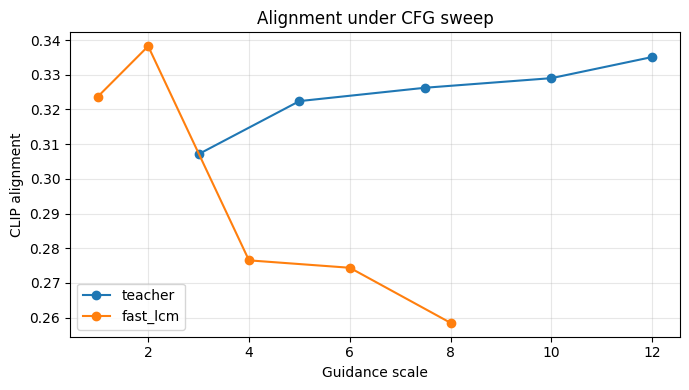

In [20]:
plt.figure(figsize=(7, 4))
for model_name in cfg_metrics_df["model"].unique():
    sub = (
        cfg_metrics_df[cfg_metrics_df["model"] == model_name]
        .groupby("guidance_scale", as_index=False)["clip_align"]
        .mean()
        .sort_values("guidance_scale")
    )
    plt.plot(sub["guidance_scale"], sub["clip_align"], marker="o", label=model_name)
plt.xlabel("Guidance scale")
plt.ylabel("CLIP alignment")
plt.title("Alignment under CFG sweep")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

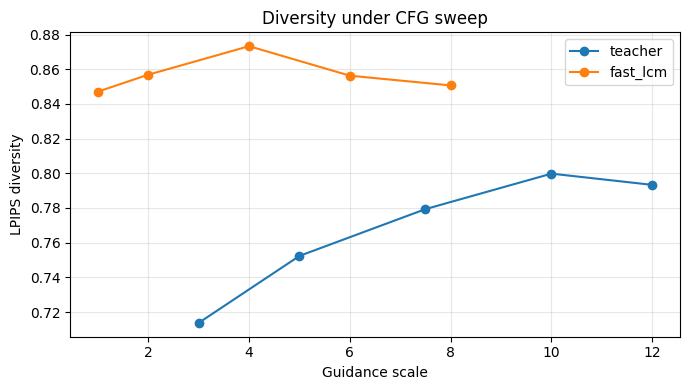

In [21]:
plt.figure(figsize=(7, 4))
for model_name in cfg_metrics_df["model"].unique():
    sub = (
        cfg_metrics_df[cfg_metrics_df["model"] == model_name]
        .groupby("guidance_scale", as_index=False)["lpips_div"]
        .mean()
        .sort_values("guidance_scale")
    )
    plt.plot(sub["guidance_scale"], sub["lpips_div"], marker="o", label=model_name)
plt.xlabel("Guidance scale")
plt.ylabel("LPIPS diversity")
plt.title("Diversity under CFG sweep")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Main experiment 3: negative prompt sensitivity

This is mostly qualitative. Quantitative metrics are still okay to log, but the key evidence will often be side-by-side examples with the same seed.

In [22]:
def run_negative_prompt_experiment(
    teacher_pipe,
    student_pipe,
    evaluator: Evaluator,
    cfg: ExperimentConfig = CFG
):
    all_runs = []
    all_metrics = []

    experiments = [
        {
            "prompt_group": "negative_prompt",
            "prompt_id": 0,
            "prompt": "a realistic photo of a black dog running on a beach",
            "conditions": [
                ("none", NEGATIVE_PROMPTS["none"]),
                ("generic", NEGATIVE_PROMPTS["generic"]),
                ("dog_targeted", NEGATIVE_PROMPTS["dog_targeted"]),
            ]
        },
        {
            "prompt_group": "negative_prompt",
            "prompt_id": 1,
            "prompt": "a realistic photo of a white car parked in front of a blue house",
            "conditions": [
                ("none", NEGATIVE_PROMPTS["none"]),
                ("generic", NEGATIVE_PROMPTS["generic"]),
                ("car_targeted", NEGATIVE_PROMPTS["car_targeted"]),
            ]
        }
    ]

    for exp in experiments:
        for neg_label, neg_prompt in exp["conditions"]:
            df_run = run_setting(
                pipe=teacher_pipe,
                model_name="teacher",
                experiment_name="negative_prompt",
                prompt_group=exp["prompt_group"],
                prompt_id=exp["prompt_id"],
                prompt=exp["prompt"],
                steps=cfg.teacher_steps[0],
                guidance_scale=cfg.teacher_cfg_default,
                seeds=cfg.seeds[:4],
                negative_prompt=neg_prompt,
                neg_label=neg_label,
                cfg=cfg
            )
            all_runs.append(df_run)
            all_metrics.append(evaluator.evaluate_setting(df_run))

            df_run = run_setting(
                pipe=student_pipe,
                model_name="fast_lcm",
                experiment_name="negative_prompt",
                prompt_group=exp["prompt_group"],
                prompt_id=exp["prompt_id"],
                prompt=exp["prompt"],
                steps=4,
                guidance_scale=cfg.student_cfg_default,
                seeds=cfg.seeds[:4],
                negative_prompt=neg_prompt,
                neg_label=neg_label,
                cfg=cfg
            )
            all_runs.append(df_run)
            all_metrics.append(evaluator.evaluate_setting(df_run))

    runs_df = pd.concat(all_runs, ignore_index=True)
    metrics_df = pd.DataFrame(all_metrics)
    runs_df.to_csv(os.path.join(cfg.output_root, "metrics", "negative_prompt_runs.csv"), index=False)
    metrics_df.to_csv(os.path.join(cfg.output_root, "metrics", "negative_prompt_metrics.csv"), index=False)
    return runs_df, metrics_df

neg_runs_df, neg_metrics_df = run_negative_prompt_experiment(teacher_pipe, student_pipe, evaluator, CFG)
neg_metrics_df.head()

teacher | negative_prompt | p0 | s30 | cfg7.5:   0%|          | 0/4 [00:00<?, ?it/s]

fast_lcm | negative_prompt | p0 | s4 | cfg2.0:   0%|          | 0/4 [00:00<?, ?it/s]

teacher | negative_prompt | p0 | s30 | cfg7.5:   0%|          | 0/4 [00:00<?, ?it/s]

fast_lcm | negative_prompt | p0 | s4 | cfg2.0:   0%|          | 0/4 [00:00<?, ?it/s]

teacher | negative_prompt | p0 | s30 | cfg7.5:   0%|          | 0/4 [00:00<?, ?it/s]

...

teacher | negative_prompt | p1 | s30 | cfg7.5:   0%|          | 0/4 [00:00<?, ?it/s]

fast_lcm | negative_prompt | p1 | s4 | cfg2.0:   0%|          | 0/4 [00:00<?, ?it/s]

teacher | negative_prompt | p1 | s30 | cfg7.5:   0%|          | 0/4 [00:00<?, ?it/s]

fast_lcm | negative_prompt | p1 | s4 | cfg2.0:   0%|          | 0/4 [00:00<?, ?it/s]

,model,experiment_name,prompt_group,prompt_id,prompt,steps,guidance_scale,negative_prompt,negative_prompt_label,lpips_div,clip_feature_var,clip_align,n_samples
0,teacher,negative_prompt,negative_prompt,0,a realistic photo of a black dog running on a ...,30,7.5,,none,0.767685,0.000227,0.361760,4
1,fast_lcm,negative_prompt,negative_prompt,0,a realistic photo of a black dog running on a ...,4,2.0,,none,0.853265,0.000212,0.359188,4
2,teacher,negative_prompt,negative_prompt,0,a realistic photo of a black dog running on a ...,30,7.5,"blurry, low quality, distorted, deformed, extr...",generic,0.749357,0.000217,0.360445,4
3,fast_lcm,negative_prompt,negative_prompt,0,a realistic photo of a black dog running on a ...,4,2.0,"blurry, low quality, distorted, deformed, extr...",generic,0.887338,0.000184,0.357281,4
4,teacher,negative_prompt,negative_prompt,0,a realistic photo of a black dog running on a ...,30,7.5,"sand, ocean, beach, water, shoreline",dog_targeted,0.785906,0.000284,0.315071,4


## Main experiment 4: compositional failure

This is mainly qualitative.

### What to annotate in the report
- object swap
- incorrect relation
- merged objects
- attribute leakage

In [23]:
composition_prompts = prompts_subset["composition"]
comp_runs = []

for pid, prompt in enumerate(composition_prompts):
    for model_name, pipe, steps, g in [
        ("teacher", teacher_pipe, 30, 7.5),
        ("fast_lcm_8", student_pipe, 8, 2.0),
        ("fast_lcm_4", student_pipe, 4, 2.0),
        ("fast_lcm_2", student_pipe, 2, 2.0),
    ]:
        df_run = run_setting(
            pipe=pipe,
            model_name=model_name,
            experiment_name="composition",
            prompt_group="composition",
            prompt_id=pid,
            prompt=prompt,
            steps=steps,
            guidance_scale=g,
            seeds=[0, 1],
            cfg=CFG
        )
        comp_runs.append(df_run)

comp_runs_df = pd.concat(comp_runs, ignore_index=True)
comp_runs_df.to_csv(os.path.join(CFG.output_root, "metrics", "composition_runs.csv"), index=False)
comp_runs_df.head()

teacher | composition | p0 | s30 | cfg7.5:   0%|          | 0/2 [00:00<?, ?it/s]

fast_lcm_8 | composition | p0 | s8 | cfg2.0:   0%|          | 0/2 [00:00<?, ?it/s]

fast_lcm_4 | composition | p0 | s4 | cfg2.0:   0%|          | 0/2 [00:00<?, ?it/s]

fast_lcm_2 | composition | p0 | s2 | cfg2.0:   0%|          | 0/2 [00:00<?, ?it/s]

teacher | composition | p1 | s30 | cfg7.5:   0%|          | 0/2 [00:00<?, ?it/s]

fast_lcm_8 | composition | p1 | s8 | cfg2.0:   0%|          | 0/2 [00:00<?, ?it/s]

fast_lcm_4 | composition | p1 | s4 | cfg2.0:   0%|          | 0/2 [00:00<?, ?it/s]

fast_lcm_2 | composition | p1 | s2 | cfg2.0:   0%|          | 0/2 [00:00<?, ?it/s]

,model,experiment_name,prompt_group,prompt_id,prompt,steps,guidance_scale,seed,negative_prompt,negative_prompt_label,image_path
0,teacher,composition,composition,0,a red cube on top of a blue sphere on a wooden...,30,7.5,0,,none,outputs/images/teacher__exp-composition__group...
1,teacher,composition,composition,0,a red cube on top of a blue sphere on a wooden...,30,7.5,1,,none,outputs/images/teacher__exp-composition__group...
2,fast_lcm_8,composition,composition,0,a red cube on top of a blue sphere on a wooden...,8,2.0,0,,none,outputs/images/fast_lcm_8__exp-composition__gr...
3,fast_lcm_8,composition,composition,0,a red cube on top of a blue sphere on a wooden...,8,2.0,1,,none,outputs/images/fast_lcm_8__exp-composition__gr...
4,fast_lcm_4,composition,composition,0,a red cube on top of a blue sphere on a wooden...,4,2.0,0,,none,outputs/images/fast_lcm_4__exp-composition__gr...


## Main experiment 5: fine-detail failure

### What to look for
- unreadable text
- wrong clock face
- missing thin structures
- smudged tiny components

In [24]:
fine_detail_prompts = prompts_subset["fine_detail"]
detail_runs = []

for pid, prompt in enumerate(fine_detail_prompts):
    for model_name, pipe, steps, g in [
        ("teacher", teacher_pipe, 30, 7.5),
        ("fast_lcm_8", student_pipe, 8, 2.0),
        ("fast_lcm_4", student_pipe, 4, 2.0),
        ("fast_lcm_2", student_pipe, 2, 2.0),
    ]:
        df_run = run_setting(
            pipe=pipe,
            model_name=model_name,
            experiment_name="fine_detail",
            prompt_group="fine_detail",
            prompt_id=pid,
            prompt=prompt,
            steps=steps,
            guidance_scale=g,
            seeds=[0, 1],
            cfg=CFG
        )
        detail_runs.append(df_run)

detail_runs_df = pd.concat(detail_runs, ignore_index=True)
detail_runs_df.to_csv(os.path.join(CFG.output_root, "metrics", "fine_detail_runs.csv"), index=False)
detail_runs_df.head()

teacher | fine_detail | p0 | s30 | cfg7.5:   0%|          | 0/2 [00:00<?, ?it/s]

fast_lcm_8 | fine_detail | p0 | s8 | cfg2.0:   0%|          | 0/2 [00:00<?, ?it/s]

fast_lcm_4 | fine_detail | p0 | s4 | cfg2.0:   0%|          | 0/2 [00:00<?, ?it/s]

fast_lcm_2 | fine_detail | p0 | s2 | cfg2.0:   0%|          | 0/2 [00:00<?, ?it/s]

teacher | fine_detail | p1 | s30 | cfg7.5:   0%|          | 0/2 [00:00<?, ?it/s]

fast_lcm_8 | fine_detail | p1 | s8 | cfg2.0:   0%|          | 0/2 [00:00<?, ?it/s]

fast_lcm_4 | fine_detail | p1 | s4 | cfg2.0:   0%|          | 0/2 [00:00<?, ?it/s]

fast_lcm_2 | fine_detail | p1 | s2 | cfg2.0:   0%|          | 0/2 [00:00<?, ?it/s]

,model,experiment_name,prompt_group,prompt_id,prompt,steps,guidance_scale,seed,negative_prompt,negative_prompt_label,image_path
0,teacher,fine_detail,fine_detail,0,a close-up photo of a wristwatch showing 10:08...,30,7.5,0,,none,outputs/images/teacher__exp-fine_detail__group...
1,teacher,fine_detail,fine_detail,0,a close-up photo of a wristwatch showing 10:08...,30,7.5,1,,none,outputs/images/teacher__exp-fine_detail__group...
2,fast_lcm_8,fine_detail,fine_detail,0,a close-up photo of a wristwatch showing 10:08...,8,2.0,0,,none,outputs/images/fast_lcm_8__exp-fine_detail__gr...
3,fast_lcm_8,fine_detail,fine_detail,0,a close-up photo of a wristwatch showing 10:08...,8,2.0,1,,none,outputs/images/fast_lcm_8__exp-fine_detail__gr...
4,fast_lcm_4,fine_detail,fine_detail,0,a close-up photo of a wristwatch showing 10:08...,4,2.0,0,,none,outputs/images/fast_lcm_4__exp-fine_detail__gr...


## Optional: early commitment visualization

This is harder and may need minor API adjustment depending on your `diffusers` version. The idea is to save intermediate denoised predictions and show that the fast model commits to structure earlier.

In [25]:
def decode_latents_to_pil(pipe, latents):
    latents = latents / pipe.vae.config.scaling_factor
    with torch.no_grad():
        image = pipe.vae.decode(latents).sample
    image = (image / 2 + 0.5).clamp(0, 1)
    image = image.detach().cpu().permute(0, 2, 3, 1).numpy()
    images = (image * 255).round().astype("uint8")
    return [Image.fromarray(img) for img in images]

def generate_with_callback(
    pipe,
    prompt: str,
    seed: int,
    num_inference_steps: int,
    guidance_scale: float,
    save_dir: str
):
    os.makedirs(save_dir, exist_ok=True)
    generator = torch.Generator(device=CFG.device).manual_seed(seed)
    captured = []

    def callback(step: int, timestep: int, latents: torch.FloatTensor):
        try:
            imgs = decode_latents_to_pil(pipe, latents)
            img = imgs[0]
            path = os.path.join(save_dir, f"step_{step:02d}_t_{int(timestep)}.png")
            img.save(path)
            captured.append(path)
        except Exception as e:
            print(f"callback decode failed at step {step}: {e}")

    with autocast_context(CFG.device):
        out = pipe(
            prompt=prompt,
            num_inference_steps=num_inference_steps,
            guidance_scale=guidance_scale,
            generator=generator,
            callback=callback,
            callback_steps=1
        )

    final_path = os.path.join(save_dir, "final.png")
    out.images[0].save(final_path)
    return captured, final_path

# Example run
# teacher_cb_dir = os.path.join(CFG.output_root, "callbacks", "teacher_example")
# student_cb_dir = os.path.join(CFG.output_root, "callbacks", "student_example")
# generate_with_callback(teacher_pipe, "a cat wearing round glasses reading a book in a library", 0, 30, 7.5, teacher_cb_dir)
# generate_with_callback(student_pipe, "a cat wearing round glasses reading a book in a library", 0, 4, 2.0, student_cb_dir)

## Save summary tables

These make report writing much easier.

In [26]:
summary_by_group_df = (
    step_metrics_df
    .groupby(["prompt_group", "model", "steps"], as_index=False)[["lpips_div", "clip_feature_var", "clip_align"]]
    .mean()
    .sort_values(["prompt_group", "model", "steps"])
)
summary_by_group_df.to_csv(os.path.join(CFG.output_root, "metrics", "summary_by_prompt_group.csv"), index=False)
summary_by_group_df.head(20)

,prompt_group,model,steps,lpips_div,clip_feature_var,clip_align
0,composition,fast_lcm,2,0.838792,0.000394,0.307251
1,composition,fast_lcm,4,0.831881,0.000200,0.334594
2,composition,fast_lcm,8,0.890693,0.000198,0.336626
3,composition,teacher,30,0.836013,0.000161,0.337678
4,control,fast_lcm,2,0.871638,0.000243,0.313202
5,control,fast_lcm,4,0.856834,0.000246,0.338249
6,control,fast_lcm,8,0.830522,0.000232,0.335775
7,control,teacher,30,0.779354,0.000333,0.326275
8,diversity,fast_lcm,2,0.788624,0.000326,0.308908
9,diversity,fast_lcm,4,0.742287,0.000186,0.320211


## Minimum experiment set for a strong final report

### Must-have
- step sweep on 8 prompts × 8 seeds
- LPIPS / CLIP variance / CLIP alignment
- line plots
- side-by-side sample grids

### Strong add-on
- CFG sweep on 2 prompts
- compositional qualitative figure
- fine-detail qualitative figure

### Optional but excellent
- early commitment visualization
- negative prompt sensitivity figure

## Suggested figure list for the paper

1. Pipeline overview: teacher vs accelerated student  
2. LPIPS diversity vs inference steps  
3. CLIP feature variance vs inference steps  
4. CLIP alignment vs inference steps  
5. Diversity–alignment tradeoff  
6. CFG sweep  
7. Compositional failure examples  
8. Fine-detail failure examples  
9. Early commitment visualization

## Best execution plan

1. Run the full **step sweep**  
2. Save all grids  
3. Inspect `step_metrics_df` and the plots  
4. Run a small CFG sweep  
5. Build one composition figure and one fine-detail figure  
6. Only then attempt early commitment visualization

Once the core plots work, your Results section is already within reach.